# 🧠 03 — Model Training
### Data Flow
```
data/02_train.csv  ─┐
data/02_val.csv    ─┤→ DNN training → outputs/best_model.pth
                    └→ TabNet training (comparison)
```


In [1]:

import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.insert(0, '..')
import os, torch, torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

os.makedirs('../outputs', exist_ok=True)
os.makedirs('plots',      exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.1)
SEED   = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")


Device: cpu


## 1. Load Processed Splits

In [2]:

df_train = pd.read_csv('../data/02_train.csv')
df_val   = pd.read_csv('../data/02_val.csv')

feature_names = [c for c in df_train.columns if c != 'DEFAULT']
N_FEATURES    = len(feature_names)

X_train = df_train[feature_names].values.astype(np.float32)
y_train = df_train['DEFAULT'].values.astype(np.float32)
X_val   = df_val[feature_names].values.astype(np.float32)
y_val   = df_val['DEFAULT'].values.astype(np.float32)

print(f"Train : {X_train.shape}  |  Default rate: {y_train.mean():.1%}")
print(f"Val   : {X_val.shape}    |  Default rate: {y_val.mean():.1%}")
print(f"Features ({N_FEATURES}): {feature_names}")


Train : (22241, 23)  |  Default rate: 28.6%
Val   : (3926, 23)    |  Default rate: 28.6%
Features (23): ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


## 2. Dataset + DataLoader

In [3]:

class CreditDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(CreditDataset(X_train, y_train),
                          batch_size=256, shuffle=True)
val_loader   = DataLoader(CreditDataset(X_val,   y_val),
                          batch_size=256, shuffle=False)
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")


Train batches: 87  |  Val batches: 16


## 3. Model Architecture

In [4]:

from src.model import CreditRiskDNN

model = CreditRiskDNN(n_features=N_FEATURES, dropout=0.3)
print(model)
print(f"\nTotal params    : {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


CreditRiskDNN(
  (attention): FeatureAttention(
    (attn): Sequential(
      (0): Linear(in_features=23, out_features=23, bias=True)
      (1): Tanh()
      (2): Linear(in_features=23, out_features=23, bias=True)
      (3): Sigmoid()
    )
  )
  (encoder): Sequential(
    (0): Linear(in_features=23, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Total params    : 14,993
Trainable params: 14,993


## 4. Training Loop

In [6]:

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total = 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()

        logits, _ = model(X_b)
        logits = logits.view(-1)       # [B]
        y_b = y_b.view(-1)             # [B]
        loss = criterion(logits, y_b)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item()
    return total / len(loader)

def eval_auc(model, loader, device):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            logits = model(X_b.to(device))[0]
            p = torch.sigmoid(logits).view(-1).cpu().tolist()
            probs.extend(p)
            labels.extend(y_b.view(-1).tolist())
    return roc_auc_score(labels, probs)

model      = model.to(DEVICE)
pos_weight = torch.tensor([2.33], device=DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

EPOCHS, PATIENCE = 100, 10
best_auc, patience_counter = 0, 0
history = {'train_loss': [], 'val_auc': [], 'lr': []}

print(f"Training DNN on {DEVICE}...")
print(f"{'Epoch':>6} | {'Loss':>8} | {'Val AUC':>8} | {'LR':>10}")
print("─" * 42)

for epoch in range(1, EPOCHS + 1):
    loss    = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_auc = eval_auc(model, val_loader, DEVICE)
    lr_now  = optimizer.param_groups[0]['lr']
    scheduler.step(val_auc)

    history['train_loss'].append(loss)
    history['val_auc'].append(val_auc)
    history['lr'].append(lr_now)

    if epoch % 10 == 0:
        print(f"{epoch:>6} | {loss:>8.4f} | {val_auc:>8.4f} | {lr_now:>10.6f}")

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), '../outputs/best_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹  Early stop at epoch {epoch}. Best Val AUC: {best_auc:.4f}")
            break

model.load_state_dict(torch.load('../outputs/best_model.pth', map_location=DEVICE))
print(f"\n✅ Best model saved → outputs/best_model.pth  (Val AUC: {best_auc:.4f})")

model.load_state_dict(torch.load('../outputs/best_model.pth', map_location=DEVICE))
print(f"\n✅ Best model saved → outputs/best_model.pth  (Val AUC: {best_auc:.4f})")


Training DNN on cpu...
 Epoch |     Loss |  Val AUC |         LR
──────────────────────────────────────────
    10 |   0.7594 |   0.7912 |   0.001000
    20 |   0.7441 |   0.7984 |   0.001000
    30 |   0.7279 |   0.8032 |   0.001000
    40 |   0.7172 |   0.8076 |   0.001000
    50 |   0.7077 |   0.8087 |   0.001000
    60 |   0.6966 |   0.8116 |   0.000500
    70 |   0.6901 |   0.8130 |   0.000250
    80 |   0.6839 |   0.8144 |   0.000250
    90 |   0.6796 |   0.8148 |   0.000250
   100 |   0.6801 |   0.8166 |   0.000250

✅ Best model saved → outputs/best_model.pth  (Val AUC: 0.8166)

✅ Best model saved → outputs/best_model.pth  (Val AUC: 0.8166)


## 5. Training Curves

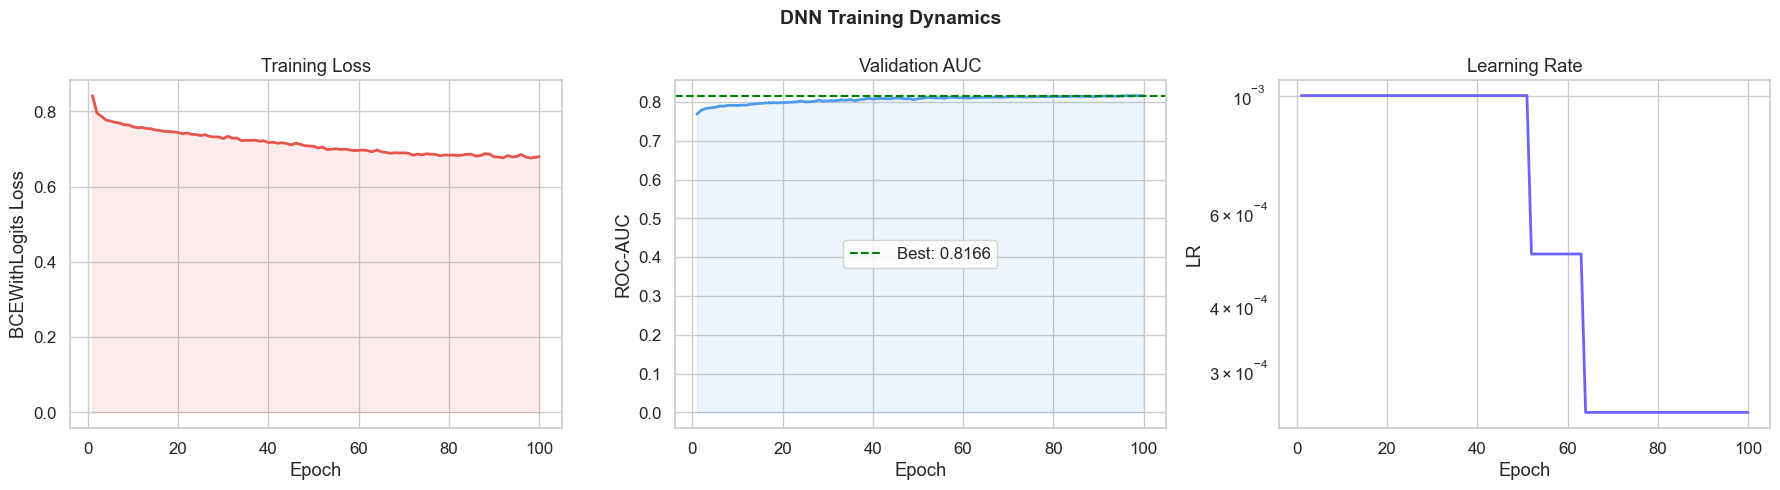

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DNN Training Dynamics', fontsize=14, fontweight='bold')
E = range(1, len(history['train_loss']) + 1)

axes[0].plot(E, history['train_loss'], color='#E8554C', linewidth=2)
axes[0].fill_between(E, history['train_loss'], alpha=0.1, color='#E8554C')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCEWithLogits Loss')

axes[1].plot(E, history['val_auc'], color='#4C9BE8', linewidth=2)
axes[1].fill_between(E, history['val_auc'], alpha=0.1, color='#4C9BE8')
axes[1].axhline(best_auc, color='green', linestyle='--',
                label=f'Best: {best_auc:.4f}')
axes[1].set_title('Validation AUC'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('ROC-AUC'); axes[1].legend()

axes[2].plot(E, history['lr'], color='#6C63FF', linewidth=2)
axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR'); axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig('plots/03_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## ✅ Summary

In [8]:

print("Training complete.")
print(f"  Best Val AUC     : {best_auc:.4f}")
print(f"  Epochs trained   : {len(history['val_auc'])}")
print(f"  Model saved to   : outputs/best_model.pth")


Training complete.
  Best Val AUC     : 0.8166
  Epochs trained   : 100
  Model saved to   : outputs/best_model.pth
